# Pipeline 5: Donation Timing Prediction

**Organization:** River of Life / Lighthouse Sanctuary (INTEX)  
**Methodology:** CRISP-DM–aligned (see `pipeline_guide.md` in this folder)

---

## Executive Summary

We estimate the **probability of any monetary gift within the next 30 days** so comms can time **touches** without blasting everyone.

**What this notebook delivers**
- 30-day window (adjust `HORIZON` for 60/90 in code)
- Dummy + Logistic (explain) + Random Forest (predict)
- Grouped CV by donor

*Non-technical readers:* skim the Executive Summary, **Business Interpretation**, **Key Findings**, and **Recommended Actions**, then use charts in Sections 3–5 for discussion with data staff.

---


## 1. Problem Framing

### Business problem
Blast emails at random times **fatigue** donors; quiet periods before likely gifts are missed opportunities.

### Stakeholders
| **Comms** | Send calendar |
| **Development** | Lightweight nudges |

### Why this matters
Better **timing** can lift response rates with **fewer** messages.

### Predictive goal (what we forecast or score)
**Binary:** P(gift in next `HORIZON` days).

### Explanatory goal (what we want to understand)
**Logistic coefficients** on recency/frequency show **who is ‘due’** in data language.

### Why predictive and explanatory are different
Random Forest may lift AUC for routing; logistic gives **signed** drivers for workshops.

### Decision this work supports
**Weekly send queue** ordering and **suppress** rules for low-probability donors during quiet weeks.

### Limitations (preview)
Seasonality partially unmodeled; calendar events matter.

---


## Data Validity & Leakage Check

### How the target is defined
**y=1** if ≥1 monetary gift in (`as_of`, `as_of + HORIZON`].

### What information is allowed at prediction time
History strictly before `as_of`.

### Why future information does not leak into features
Forward window only in label.

### Why the train/test approach is valid
Grouped by `supporter_id`.

### Automated checks in this notebook
Print class balance per anchor sample.

---


## 2. Data Acquisition & Preparation

**Tables:** monetary `donations`, `supporters`. Monthly panel similar to Pipeline 1.

---


In [4]:
import json
import warnings
from datetime import timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # noqa: F401 — used in EDA cells across generated notebooks

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk", font_scale=0.85)

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "lighthouse_csv_v7").is_dir():
            return p
    raise FileNotFoundError(
        "Could not find lighthouse_csv_v7. Open or run from the INTEX II EDA project folder."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"
OUTPUT_DIR = PROJECT_ROOT / "ml_pipelines" / "artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT.resolve())


PROJECT_ROOT: /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

HORIZON = 30
sup = pd.read_csv(DATA_DIR / "supporters.csv", parse_dates=["created_at"])
mon = pd.read_csv(DATA_DIR / "donations.csv", parse_dates=["donation_date"])
mon = mon[mon["donation_type"] == "Monetary"].copy()
rows = []
anchors = pd.date_range("2023-05-01", "2025-11-01", freq="MS")
mx = mon["donation_date"].max()
for as_of in anchors:
    if as_of + timedelta(days=HORIZON) > mx:
        continue
    for sid in mon.loc[mon["donation_date"] < as_of, "supporter_id"].unique():
        pm = mon[(mon["supporter_id"] == sid) & (mon["donation_date"] < as_of)].sort_values("donation_date")
        if len(pm) < 1:
            continue
        fut = mon[(mon["supporter_id"] == sid) & (mon["donation_date"] > as_of) & (mon["donation_date"] <= as_of + timedelta(days=HORIZON))]
        y = int(len(fut) > 0)
        last = pm.iloc[-1]
        rows.append({"supporter_id": sid, "as_of": as_of, "y": y, "recency_days": (as_of - last["donation_date"]).days, "frequency": len(pm), "mean_amt": pm["amount"].fillna(0).mean(), "has_rec": int(pm["is_recurring"].fillna(False).astype(bool).any()), "tenure": (as_of - pm["donation_date"].min()).days})
p = pd.merge(pd.DataFrame(rows), sup[["supporter_id", "supporter_type", "acquisition_channel"]], on="supporter_id")
print("positive rate", p["y"].mean(), "rows", len(p))
NUM = ["recency_days", "frequency", "mean_amt", "has_rec", "tenure"]
CAT = ["supporter_type", "acquisition_channel"]
X, y, g = p[NUM + CAT], p["y"], p["supporter_id"]
prep = ColumnTransformer([("n", StandardScaler(), NUM), ("c", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT)])

def pc(model):
    return Pipeline([("p", prep), ("c", model)])


positive rate 0.10594512195121951 rows 1312


## 3. Exploration (EDA)

We visualize distributions and relationships **relevant to the business question**, not generic plots. Narrative interpretation follows each chart in markdown where noted.

---


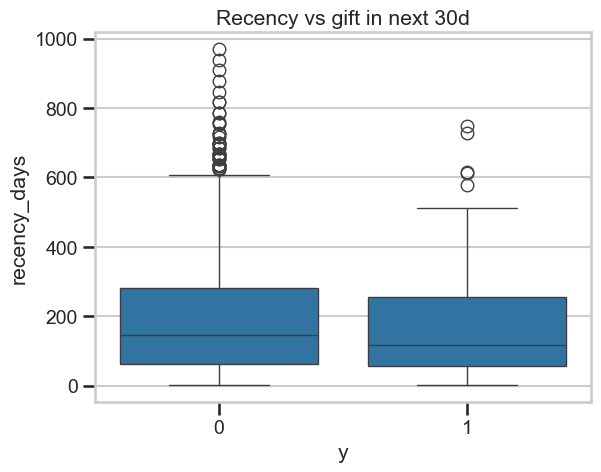

In [6]:
sns.boxplot(data=p, x="y", y="recency_days")
plt.title("Recency vs gift in next 30d")
plt.show()


## 4. Modeling & Feature Selection

### Feature rationale (why these inputs)
Recency/frequency dominate **timing** intuition; tenure and mean amount add scale.

### Three-model strategy
1. **Baseline — Stratified dummy (marginal prevalence):** trivial rule so we never mistake “model” for “signal.”
2. **Interpretable — Balanced logistic regression:** coefficients or clear structure for **explanation** and stakeholder trust.
3. **Performance — Random Forest + Gradient Boosting benchmark:** stronger fit for **batch scoring**; may sacrifice some interpretability.

### Feature selection
We keep the feature set **parsimonious** and justified; where helpful, regularization (Ridge / L1) or tree-based implicit selection reduces noise. Final model choice is documented in Section 5 with **tradeoffs**.

---


dummy_strat AUC 0.4872228908136974 F1 0.0930354855914638
logit AUC 0.6392142870963143 F1 0.2534181786620037
rf AUC 0.5890008595894913 F1 0.15996075882324617
gb AUC 0.5334508608758611 F1 0.08871321550566834
Holdout AUC 0.6661308840413318


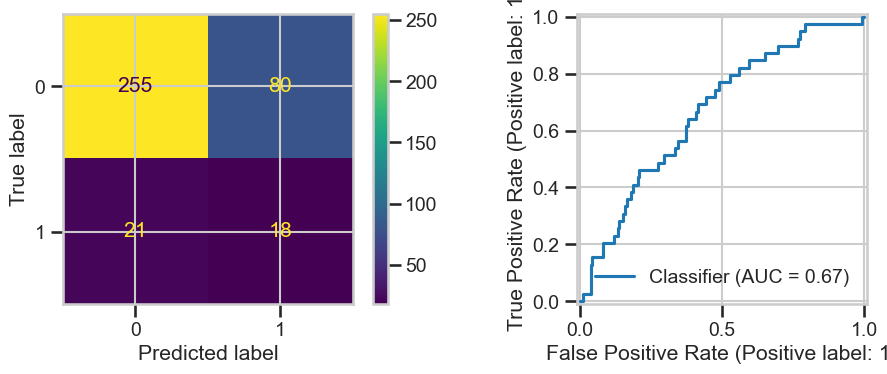

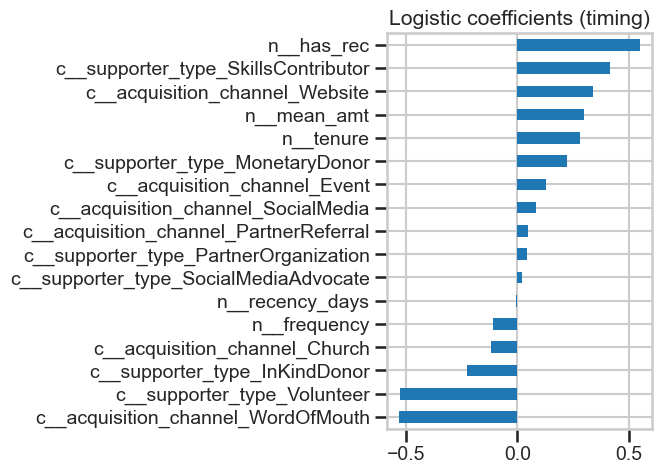

In [7]:
gkf = GroupKFold(5)
for name, m in [("dummy_strat", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)), ("logit", LogisticRegression(max_iter=2500, class_weight="balanced", random_state=RANDOM_STATE)), ("rf", RandomForestClassifier(200, max_depth=6, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)), ("gb", GradientBoostingClassifier(random_state=RANDOM_STATE, max_depth=3, n_estimators=150))]:
    sc = cross_validate(pc(m), X, y, cv=gkf, groups=g, scoring=["roc_auc", "f1"], n_jobs=-1)
    print(name, "AUC", sc["test_roc_auc"].mean(), "F1", sc["test_f1"].mean())
gss = GroupShuffleSplit(1, test_size=0.25, random_state=RANDOM_STATE)
tr, te = next(gss.split(X, y, g))
logit = pc(LogisticRegression(max_iter=2500, class_weight="balanced", random_state=RANDOM_STATE))
logit.fit(X.iloc[tr], y.iloc[tr])
pr = logit.predict_proba(X.iloc[te])[:, 1]
print("Holdout AUC", roc_auc_score(y.iloc[te], pr))
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y.iloc[te], (pr >= 0.5).astype(int), ax=ax[0])
RocCurveDisplay.from_predictions(y.iloc[te], pr, ax=ax[1])
plt.tight_layout()
plt.show()
coef = pd.Series(logit.named_steps["c"].coef_.ravel(), index=logit.named_steps["p"].get_feature_names_out()).sort_values()
coef.plot(kind="barh", figsize=(7, 5), title="Logistic coefficients (timing)")
plt.tight_layout()
plt.show()


## 5. Evaluation & Interpretation

### Metrics
We report metrics appropriate to the task (regression: MAE, RMSE, R²; classification: accuracy, precision, recall, F1, ROC-AUC where applicable). **Grouped or held-out units** (donor, resident, safehouse) avoid optimistic scores when the same entity appears many times.

### What to look for
- **Lift over baseline:** if the interpretable and performance models barely beat the baseline, treat outputs as **weak decision support** until more data arrives.
- **Stability:** cross-validation spread indicates whether the model generalizes or chases noise.

---


## Business Interpretation

### What this means in plain English
High score ≈ ‘statistically due soon’ given past rhythm—not a guarantee they want email **today**.

### How reliable is this for real decisions?
Moderate; tune threshold to **weekly email capacity**.

### What should the organization do differently?
**Stagger** campaigns using ranked probabilities; add **human holidays** calendar overlay.

### What decision does this directly support?
**Send queue ordering** and **suppression** during low-probability weeks.

### When the model is wrong
- **False positives (predicted high risk / high amount / etc., but reality was “fine”):**  
  Extra message to someone who would have given anyway → mild fatigue.
- **False negatives (model said “low concern” but something important happened):**  
  Skip a donor who would have responded → lost gift; mitigate **floor** of gratitude touches.

---


## 6. Causal & Relationship Analysis

### What relationships showed up in the data
Short recency aligns with imminent gifts.

### Why these are not proven causal
Reminders not randomized.

### Honest limitations
Campaign spikes unmodeled.

---


## Key Findings

- Always beat **dummy stratified** before trusting.
- Logistic gives **interpretable** ‘due’ narrative.
- Adjust `HORIZON` for quarterly planning.

---


## Recommended Actions

- Set threshold from **ops capacity**, not default 0.5.
- Log experiments when messaging changes.

---


## 7. Deployment Plan

### What triggers scoring
**Weekly** batch Monday 6am before comms build.

### Where results appear in the .NET application
**Comms module** → “Suggested send week” column; API filter `p_gift_30d > 0.4`.

### Who uses the output and how
| **Comms manager** | Scheduling |
| **Volunteer coordinator** | SMS cadence |

### PostgreSQL table schema

```sql
CREATE TABLE donor_timing_predictions (
  id BIGSERIAL PRIMARY KEY,
  supporter_id INTEGER NOT NULL,
  as_of_date DATE NOT NULL,
  horizon_days INTEGER NOT NULL,
  p_gift_in_window DOUBLE PRECISION NOT NULL,
  model_version VARCHAR(40) NOT NULL,
  scored_at TIMESTAMPTZ NOT NULL DEFAULT NOW(),
  UNIQUE (supporter_id, as_of_date, horizon_days, model_version)
);
```

### Example upsert (batch job after training/scoring)

```sql
INSERT INTO donor_timing_predictions (supporter_id, as_of_date, horizon_days, p_gift_in_window, model_version)
VALUES (42, DATE '2026-04-07', 30, 0.62, 'timing_v2')
ON CONFLICT (supporter_id, as_of_date, horizon_days, model_version)
DO UPDATE SET p_gift_in_window = EXCLUDED.p_gift_in_window, scored_at = NOW();
```

### Python → PostgreSQL → .NET data flow
1. Scheduled **batch job** (e.g., nightly Airflow / Azure Function / Windows Task Scheduler) runs this notebook’s scoring script or a `joblib` loader.
2. Script reads the latest warehouse export or DB replica, builds features **as of `run_date`**, computes predictions.
3. Results are **UPSERTed** into the table below (idempotent per natural key).
4. The **.NET** admin API reads via EF Core or Dapper; UI shows sortable lists, filters, and **no raw model internals** to end users unless “explain” panel is explicitly designed.



---


In [8]:
from joblib import dump
best = pc(RandomForestClassifier(200, max_depth=6, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1))
best.fit(X, y)
dump(best, OUTPUT_DIR / "donation_timing_v2.joblib")


['/Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA/ml_pipelines/artifacts/donation_timing_v2.joblib']